# Notebook 04 — Question Bank Builder

Membangun bank soal quiz CVD dari gambar buah. Setiap soal terdiri dari
**satu base image** yang dirender tiga kali dengan hue berbeda:
satu target (warna asli) dan dua distractor (hue digeser terkontrol).

## Prinsip Desain

| Aspek | Keputusan |
|-------|-----------|
| **Distractor** | Digeser sepanjang confusion line CIE 1931 dari copunctal CVD |
| **Difficulty** | Mengontrol delta hue: easy=35-55°, medium=18-35°, hard=5-18° |
| **Framing soal** | "Pilih warna X yang kamu lihat" → persepsi, bukan hafalan |
| **Hue range → CVD** | red_orange → protanopia, green_yellow → deuteranopia |
| **Struktur folder** | quiz_images/{hue_range}/{difficulty}/soal_{N}/{class}_{role}.jpg |

## Tahapan

| Cell | Tahap | Deskripsi |
|------|-------|-----------|
| 2 | Konstanta | Semua parameter di satu cell |
| 3 | 4A | Load NB02 + NB03 prerequisites |
| 4 | 4B | Fungsi konversi warna (self-contained) |
| 5 | 4C | Compute confusion-line delta hue |
| 6 | 4D | HSV hue shift + file I/O |
| 7 | 4E | Demo visual per difficulty |
| 8 | 4F | Generate satu entri soal |
| 9 | 4G | Batch generation + numbering soal |
| 10 | 4H | Validasi & statistik |
| 11 | 4I | Ekspor question_bank.json |


In [12]:
%pip install opencv-python numpy matplotlib tqdm -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import json, uuid, random, datetime, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings("ignore")

RESEARCH_ROOT  = Path(r"C:\Colorblind_correction\research")
FRUIT_FILTERED = RESEARCH_ROOT / "datasets" / "processed" / "fruit_filtered"
NB02_OUTPUT    = RESEARCH_ROOT / "notebooks" / "02" / "output"
NB03_OUTPUT    = RESEARCH_ROOT / "notebooks" / "03" / "output"
NB04_OUTPUT    = RESEARCH_ROOT / "notebooks" / "04" / "output"
IMAGES_DIR     = NB04_OUTPUT / "quiz_images"
NB04_OUTPUT.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# red_orange -> protanopia (defisiensi cone-L), green_yellow -> deuteranopia
# (defisiensi cone-M)
HUE_RANGE_CVD: dict[str, str] = {
    "red_orange"  : "protanopia",
    "green_yellow": "deuteranopia",
}

# Delta dikontrol langsung di hue space (bukan chromaticity step). Distractor 1
# Distractor 1 digeser +delta dari target (menjauhi copunctal di confline).
# Distractor 2 digeser -delta dari target (mendekati copunctal di confline).
# Delta disampling uniform dari [delta_min, delta_max] per soal

# Kalibrasi:
# easy = beda sangat jelas, medium = perlu fokus, hard = halus tapi masih bisa dibedakan mata normal.
DELTA_RANGE: dict[str, tuple[float, float]] = {
    "easy"  : (35.0, 55.0),
    "medium": (20.0, 35.0),
    "hard"  : ( 8.0, 20.0),
}

MIN_DISTRACTOR_DIFF: float = 8.0   # jarak minimum antar dua distractor (derajat)
ERROR_WEIGHT: dict[str, int] = {"easy": 3, "medium": 2, "hard": 0.5}   # bobot skor adaptive engine

# Nama warna granular (15 segmen) agar teks soal cukup spesifik membimbing mata
# normal ke target yang tepat, terutama di medium/hard difficulty saat distractor mirip target. 
# Compound hue terms (kuning-hijau, oranye-merah) diproses natural
# oleh manusia dan meningkatkan akurasi identifikasi warna transisi dibanding single-word label.

# Tuple: (batas_atas_eksklusif_derajat, nama_warna).
HUE_COLOR_NAMES: list[tuple[float, str]] = [
    (  5.0, "orange gelap"),
    ( 10.0, "merah"),
    ( 17.0, "merah terang"),
    ( 26.0, "merah-oranye"),
    ( 30.0, "oranye-merah"),
    ( 40.0, "oranye"),
    ( 48.0, "oranye-kuning"),
    ( 55.0, "kuning-oranye"),
    ( 60.0, "kuning"),
    ( 77.0, "kuning-hijau"),
    ( 100.0, "hijau-kuning"),
    (120.0, "hijau muda"),
    (145.0, "hijau"),
    (160.0, "hijau tua"),
    (180.0, "hijau gelap"),
]
# Zona 330-360 derajat: merah keunguan (pomegranate, strawberry gelap, dst)
HUE_HIGH_COLOR_NAME: str  = "merah keunguan"
HUE_HIGH_THRESHOLD : float = 330.0

TARGET_SIZE   : int   = 224   # resolusi gambar quiz (px)
JPEG_QUALITY  : int   = 90
SAT_THRESHOLD : float = 0.20  # piksel di bawah ini dianggap background, diabaikan saat hitung hue dominan

RANDOM_SEED: int = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("[Cell 2] Konstanta siap:")
print(f"  FRUIT_FILTERED  : {FRUIT_FILTERED}")
print(f"  NB02_OUTPUT     : {NB02_OUTPUT}")
print(f"  NB03_OUTPUT     : {NB03_OUTPUT}")
print(f"  NB04_OUTPUT     : {NB04_OUTPUT}")
print(f"  HUE_RANGE_CVD   : {HUE_RANGE_CVD}")
print(f"  DELTA_RANGE     : {DELTA_RANGE}")
print(f"  TARGET_SIZE     : {TARGET_SIZE}px")


[Cell 2] Konstanta siap:
  FRUIT_FILTERED  : C:\Colorblind_correction\research\datasets\processed\fruit_filtered
  NB02_OUTPUT     : C:\Colorblind_correction\research\notebooks\02\output
  NB03_OUTPUT     : C:\Colorblind_correction\research\notebooks\03\output
  NB04_OUTPUT     : C:\Colorblind_correction\research\notebooks\04\output
  HUE_RANGE_CVD   : {'red_orange': 'protanopia', 'green_yellow': 'deuteranopia'}
  DELTA_RANGE     : {'easy': (35.0, 55.0), 'medium': (20.0, 35.0), 'hard': (8.0, 20.0)}
  TARGET_SIZE     : 224px


In [14]:
# Image index dibangun dari scan folder fruit_filtered, bukan dari urutan
# extraction_results.json karena undersampling NB02 membuat jumlah file
# lebih sedikit dari jumlah record (misal 1873 RO record vs 688 RO file).
# Iterasi seluruh record tanpa index akan banyak menghasilkan record tanpa
# file pasangan (invalid rate tinggi).

def load_prerequisites(nb02_output: Path, nb03_output: Path) -> tuple[list[dict], dict, dict, dict, tuple]:
    """Load extraction_results.json (NB02) dan confusion_line_validation.json (NB03).

    COPUNCTAL dan WHITE_D65 sekarang diambil dari parameter NB03 (bukan
    hardcode independen), agar NB04 benar-benar mewarisi nilai yang sudah
    divalidasi di NB03, bukan cuma menyalin angka literatur secara terpisah.
    """
    ext_path = nb02_output / "extraction_results.json"
    val_path = nb03_output / "confusion_line_validation.json"

    for p in (ext_path, val_path):
        if not p.exists():
            raise FileNotFoundError(f"{p} tidak ditemukan. Pastikan notebook sebelumnya sudah dijalankan.")

    with open(ext_path, encoding="utf-8") as f:
        ext_data: list[dict] = json.load(f)
    with open(val_path, encoding="utf-8") as f:
        val_data: dict = json.load(f)

    train_records = [
        r for r in ext_data
        if r["subset"] == "train" and r["status"] == "success"
    ]

    hue_bounds  = val_data["hue_boundaries_source"]
    val_summary = val_data["summary"]

    if val_summary.get("validated", 0) == 0:
        raise RuntimeError("NB03 validated = 0. Periksa NB03 sebelum lanjut ke NB04.")

    # ambil copunctal & white point dari NB03
    params    = val_data["parameters"]
    copunctal = {k: tuple(v) for k, v in params["copunctal_points"].items()}
    white_d65 = tuple(params["white_point_d65"])

    return train_records, hue_bounds, val_summary, copunctal, white_d65


def build_image_index(
    fruit_filtered: Path,
    train_records : list[dict],
    subset        : str = "train",
) -> dict[tuple[str, str], list[Path]]:
    """Scan fruit_filtered, bangun index file per (folder_name, hue_range).

    File dipetakan ke kelas via exact prefix matching pada stem nama file,
    bukan substring — 'pear' in 'pineapple' akan salah memetakan file
    pineapple ke kelas pear jika pakai substring match.
    """
    subset_dir = fruit_filtered / subset
    if not subset_dir.exists():
        raise FileNotFoundError(f"Direktori {subset_dir} tidak ditemukan. Pastikan NB02 sudah dijalankan.")

    valid_folder_names = sorted({r["folder_name"] for r in train_records})
    folder_aliases: dict[str, tuple[str, str]] = {
        fn: (fn.lower(), fn[3:].lower())
        for fn in valid_folder_names
    }

    index: dict[tuple[str, str], list[Path]] = defaultdict(list)
    n_unmatched = 0

    for hue_dir in subset_dir.iterdir():
        if not hue_dir.is_dir():
            continue
        hue_range = hue_dir.name

        for p in hue_dir.iterdir():
            if not (p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}):
                continue

            stem = p.stem.lower()
            matched_folder: str | None = None

            for folder_name, (folder_key, class_name) in folder_aliases.items():
                if (
                    stem == folder_key
                    or stem.startswith(folder_key + "_")
                    or stem == class_name
                    or stem.startswith(class_name + "_")
                ):
                    matched_folder = folder_name
                    break

            if matched_folder is not None:
                index[(matched_folder, hue_range)].append(p)
            else:
                n_unmatched += 1

    for key in index:
        index[key].sort()   # deterministik lintas OS

    if n_unmatched > 0:
        print(f"  [WARN] {n_unmatched} file tidak cocok ke kelas manapun "
              f"— kemungkinan file non-buah di folder fruit_filtered.")

    return dict(index)


def build_indexed_records(
    train_records: list[dict],
    image_index  : dict[tuple[str, str], list[Path]],
) -> list[dict]:
    """Join train_records dengan image_index via posisi index (keduanya deterministik/sorted).

    Record ke-N dari kelas X -> file ke-N dari kelas X. Record tanpa file
    pasangan (akibat undersampling NB02) otomatis dilewati.
    """
    grouped: dict[tuple[str, str], list[dict]] = defaultdict(list)
    for rec in train_records:
        key = (rec["folder_name"], rec["hue_range"])
        grouped[key].append(rec)

    indexed: list[dict] = []
    for key, recs in grouped.items():
        files = image_index.get(key, [])
        for idx, rec in enumerate(recs):
            if idx >= len(files):
                break
            enriched = {**rec, "source_image_path": files[idx]}
            indexed.append(enriched)

    return indexed


train_records, hue_bounds, val_summary, COPUNCTAL, WHITE_D65 = load_prerequisites(NB02_OUTPUT, NB03_OUTPUT)
image_index = build_image_index(FRUIT_FILTERED, train_records, subset="train")
indexed_records = build_indexed_records(train_records, image_index)

hue_dist_raw = Counter(r["hue_range"] for r in train_records)
hue_dist_idx = Counter(r["hue_range"] for r in indexed_records)

print(f"[4A] NB02 train records (all)    : {len(train_records):,}")
print(f"[4A] NB02 train records (matched): {len(indexed_records):,}")
print(f"[4A] Raw hue dist                : {dict(hue_dist_raw)}")
print(f"[4A] Matched hue dist            : {dict(hue_dist_idx)}")
print(f"[4A] Record skipped (undersampl) : {len(train_records)-len(indexed_records):,}")
print()
print(f"[4A] NB03 validated plates  : {val_summary['validated']}")
print(f"[4A] Validation rate        : {val_summary['validation_rate_evaluable']}%")
print()
print(f"[4A] Hue boundary (NB00 via NB03):")
print(f"  red_orange  : h <= {hue_bounds['red_orange_max']} atau h >= {hue_bounds['red_orange_min']}")
print(f"  green_yellow: {hue_bounds['green_yellow_min']} < h <= {hue_bounds['green_yellow_max']}")
print()

print(f"[4A] Files per kelas (matched):")
print(f"  {'Kelas':<16} {'Hue range':<14} {'N files':>8}")
print(f"  {'─'*16} {'─'*14} {'─'*8}")
for (folder, hr), files in sorted(image_index.items()):
    n_matched = sum(1 for r in indexed_records
                    if r["folder_name"]==folder and r["hue_range"]==hr)
    print(f"  {folder:<16} {hr:<14} {n_matched:>8}")


[4A] NB02 train records (all)    : 2,348
[4A] NB02 train records (matched): 1,228
[4A] Raw hue dist                : {'red_orange': 1734, 'green_yellow': 614}
[4A] Matched hue dist            : {'red_orange': 614, 'green_yellow': 614}
[4A] Record skipped (undersampl) : 1,120

[4A] NB03 validated plates  : 3
[4A] Validation rate        : 100.0%

[4A] Hue boundary (NB00 via NB03):
  red_orange  : h <= 35 atau h >= 330
  green_yellow: 65 < h <= 75

[4A] Files per kelas (matched):
  Kelas            Hue range       N files
  ──────────────── ────────────── ────────
  001apple         red_orange          116
  002orange        red_orange          110
  003pear          green_yellow         78
  004tomato        red_orange           86
  005strawberry    red_orange          138
  006banana        green_yellow        136
  006banana        red_orange            2
  007watermelon    green_yellow        181
  009peach         red_orange           72
  010pomegranate   green_yellow          2
  

In [15]:
# Fungsi konversi warna self-contained (identik NB03) — tidak diimport dari
# modul eksternal, agar NB04 bisa dijalankan independen dari NB03.

def _srgb_linearize(c: float) -> float:
    """sRGB gamma ke linear light (IEC 61966-2-1)."""
    return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4


def rgb_to_xy(r: float, g: float, b: float) -> tuple[float | None, float | None]:
    """sRGB ke CIE 1931 xy (matriks IEC 61966-2-1, identik NB03). None jika warna terlalu gelap (XYZ < 1e-6)."""
    rl, gl, bl = _srgb_linearize(r), _srgb_linearize(g), _srgb_linearize(b)
    X = 0.4124564*rl + 0.3575761*gl + 0.1804375*bl
    Y = 0.2126729*rl + 0.7151522*gl + 0.0721750*bl
    Z = 0.0193339*rl + 0.1191920*gl + 0.9503041*bl
    s = X + Y + Z
    if s < 1e-6:
        return None, None
    return X / s, Y / s


def hue360_to_rgb(hue_360: float, sat: float = 0.75, val: float = 0.85) -> tuple[float, float, float]:
    """Hue 0-360 ke sRGB representatif (sat/val tipikal buah berwarna, bukan untuk reproduksi warna eksak)."""
    h  = hue_360 % 360.0
    hi = int(h / 60.0) % 6
    f  = h / 60.0 - int(h / 60.0)
    p, q, t = val*(1-sat), val*(1-f*sat), val*(1-(1-f)*sat)
    return [(val,t,p),(q,val,p),(p,val,t),(p,q,val),(t,p,val),(val,p,q)][hi]


def xy_to_hue360(x: float, y: float) -> float:
    """CIE xy ke hue 0-360 via aproksimasi sRGB (asumsi Y=0.5, cukup untuk arah hue di confusion line)."""
    Y  = 0.5
    X  = x * Y / max(y, 1e-6)
    Z  = (1.0 - x - y) * Y / max(y, 1e-6)

    rl =  3.2404542*X - 1.5371385*Y - 0.4985314*Z
    gl = -0.9692660*X + 1.8760108*Y + 0.0415560*Z
    bl =  0.0556434*X - 0.2040259*Y + 1.0572252*Z

    def _gamma(c: float) -> float:
        c = max(0.0, min(1.0, c))
        return 1.055 * c**0.41667 - 0.055 if c > 0.0031308 else 12.92 * c

    r, g, b = _gamma(rl), _gamma(gl), _gamma(bl)
    mx, mn  = max(r, g, b), min(r, g, b)
    d       = mx - mn
    if d < 1e-6:
        return 0.0
    if   mx == r: h = ((g - b) / d) % 6.0
    elif mx == g: h = (b - r) / d + 2.0
    else        : h = (r - g) / d + 4.0
    return (h * 60.0) % 360.0


print("[Cell 4] Fungsi konversi warna siap.")
print()
# Verifikasi roundtrip: hue in -> xy -> hue out, error harus < 15 derajat
print(f"  {'Hue in':>8}  {'x':>7}  {'y':>7}  {'Hue out':>9}  {'Error':>7}")
print(f"  {'─'*8}  {'─'*7}  {'─'*7}  {'─'*9}  {'─'*7}")
for h in [8.0, 16.0, 35.0, 70.0, 100.0]:
    r, g, b = hue360_to_rgb(h)
    x, y    = rgb_to_xy(r, g, b)
    if x:
        h_out = xy_to_hue360(x, y)
        print(f"  {h:>8.1f}  {x:>7.4f}  {y:>7.4f}  {h_out:>9.1f}  {abs(h-h_out):>6.1f} deg")


[Cell 4] Fungsi konversi warna siap.

    Hue in        x        y    Hue out    Error
  ────────  ───────  ───────  ─────────  ───────
       8.0   0.5514   0.3493       11.2     3.2 deg
      16.0   0.5283   0.3723       20.2     4.2 deg
      35.0   0.4707   0.4297       35.0     0.0 deg
      70.0   0.3881   0.5055       70.0     0.0 deg
     100.0   0.3273   0.5479      100.0     0.0 deg


In [16]:
def confusion_line_hue(
    base_hue_360: float,
    cvd_type    : str,
    delta_deg   : float,
    direction   : int,
) -> float:
    """Hitung hue hasil pergeseran sepanjang confusion line dari base_hue.

    Pipeline: base_hue -> xy -> geser delta chromaticity sepanjang confline -> hue baru.
    Konversi delta_deg (target pergeseran hue) ke satuan chromaticity dilakukan
    via bisection karena hubungan hue-to-chromaticity tidak linear.
    """
    xc, yc = COPUNCTAL[cvd_type]
    xd, yd = WHITE_D65

    # Posisi base hue di chromaticity diagram
    r0, g0, b0 = hue360_to_rgb(base_hue_360)
    x0, y0     = rgb_to_xy(r0, g0, b0)
    if x0 is None:
        return (base_hue_360 + direction * delta_deg) % 360.0   # fallback linear, warna terlalu gelap

    dx, dy = xd - xc, yd - yc
    norm   = np.sqrt(dx*dx + dy*dy)
    ux, uy = dx / norm, dy / norm

    # Bisection: cari step chromaticity yang menghasilkan delta hue ~ delta_deg
    step_lo, step_hi = 0.001, 0.300
    for _ in range(30):   # 30 iterasi cukup untuk konvergensi < 0.01 derajat
        step_mid = (step_lo + step_hi) / 2.0
        x_try    = x0 + direction * ux * step_mid
        y_try    = y0 + direction * uy * step_mid
        h_try    = xy_to_hue360(x_try, y_try)
        achieved = abs((h_try - base_hue_360 + 180) % 360 - 180)
        if achieved < delta_deg:
            step_lo = step_mid
        else:
            step_hi = step_mid

    x_new = x0 + direction * ux * ((step_lo + step_hi) / 2.0)
    y_new = y0 + direction * uy * ((step_lo + step_hi) / 2.0)
    return xy_to_hue360(x_new, y_new)


def generate_distractor_hues(
    base_hue_360: float,
    hue_range   : str,
    difficulty  : str,
    rng         : random.Random,
) -> tuple[float, float]:
    """Generate dua hue distractor untuk satu soal.

    Delta ditetapkan langsung di hue space (bukan lewat confusion_line_hue()):
    di zona merah-pink (h=320-360 derajat) gradien hue/chromaticity sangat
    flat, sehingga step chromaticity besar bisa menghasilkan delta hue kecil
    dan distractor jadi hampir identik target. Sampling langsung di hue space
    menjamin delta sesuai difficulty; validate_entry() mengaudit hasil akhir.

    Constraint: dist1 = base+delta, dist2 = base-delta (dua sisi spektrum),
    dan |dist1-dist2| >= MIN_DISTRACTOR_DIFF (agar keduanya tidak identik).
    """
    d_min, d_max = DELTA_RANGE[difficulty]
    delta = rng.uniform(d_min, d_max)

    hue_d1 = (base_hue_360 + delta) % 360.0
    hue_d2 = (base_hue_360 - delta) % 360.0

    diff_between = abs((hue_d1 - hue_d2 + 180) % 360 - 180)
    if diff_between < MIN_DISTRACTOR_DIFF:
        hue_d2 = (hue_d2 - MIN_DISTRACTOR_DIFF) % 360.0

    return round(hue_d1, 2), round(hue_d2, 2)


print("[Cell 5] Fungsi confusion-line distractor siap.")
print()
print("  Verifikasi delta hue yang dihasilkan per difficulty:")
print(f"  {'Base hue':>9}  {'Hue range':<14}  {'Diff':>8}  "
      f"{'Dist1 hue':>10}  {'Dist2 hue':>10}  "
      f"{'|D-T|1':>7}  {'|D-T|2':>7}")
print(f"  {'─'*9}  {'─'*14}  {'─'*8}  {'─'*10}  {'─'*10}  {'─'*7}  {'─'*7}")

_rng_v = random.Random(RANDOM_SEED)
for base_h, hr in [(16.0, "red_orange"), (70.0, "green_yellow")]:
    for diff in ["easy", "medium", "hard"]:
        h1, h2 = generate_distractor_hues(base_h, hr, diff, _rng_v)
        gap1 = abs((h1 - base_h + 180) % 360 - 180)
        gap2 = abs((h2 - base_h + 180) % 360 - 180)
        print(f"  {base_h:>9.1f}  {hr:<14}  {diff:>8}  "
              f"{h1:>10.1f}  {h2:>10.1f}  "
              f"{gap1:>6.1f} deg  {gap2:>6.1f} deg")


[Cell 5] Fungsi confusion-line distractor siap.

  Verifikasi delta hue yang dihasilkan per difficulty:
   Base hue  Hue range           Diff   Dist1 hue   Dist2 hue   |D-T|1   |D-T|2
  ─────────  ──────────────  ────────  ──────────  ──────────  ───────  ───────
       16.0  red_orange          easy        63.8       328.2    47.8 deg    47.8 deg
       16.0  red_orange        medium        36.4       355.6    20.4 deg    20.4 deg
       16.0  red_orange          hard        27.3         4.7    11.3 deg    11.3 deg
       70.0  green_yellow        easy       109.5        30.5    39.5 deg    39.5 deg
       70.0  green_yellow      medium       101.0        39.0    31.1 deg    31.1 deg
       70.0  green_yellow        hard        86.1        53.9    16.1 deg    16.1 deg


In [17]:
# Tahap 4D: HSV hue shift, file I/O, nama warna dinamis
def hue_to_color_name(hue_360: float) -> str:
    """Konversi hue ke nama warna Bahasa Indonesia granular (15 segmen).

    Granularitas tinggi diperlukan agar teks soal cukup spesifik membimbing
    mata normal ke target yang tepat, terutama di medium/hard difficulty.
    Contoh: h=88.5 -> 'hijau-kuning', h=78.5 -> 'kuning-hijau', h=98.5 ->
    'hijau muda' — tiga nama berbeda untuk hue yang hanya 10 derajat terpisah.
    """
    h = hue_360 % 360.0
    if h >= HUE_HIGH_THRESHOLD:
        return HUE_HIGH_COLOR_NAME
    for batas, nama in HUE_COLOR_NAMES:
        if h < batas:
            return nama
    return HUE_COLOR_NAMES[-1][1]


def make_question_text(hue_360: float) -> str:
    """Buat teks soal dinamis dari hue dominan target, misal 'Pilih gambar dengan warna hijau-kuning yang kamu lihat'."""
    color_name = hue_to_color_name(hue_360)
    return f"Pilih gambar dengan warna {color_name} yang kamu lihat"


def apply_hue_shift(image_path: Path, target_hue: float, current_hue_360: float) -> np.ndarray | None:
    """Load gambar, geser hue dari current_hue_360 (hue asli, dari NB02) ke target_hue.

    current_hue_360 WAJIB diisi dari base_hue/dominant_hue_360 (hasil K-Means
    NB02 yang sudah difilter dominance ratio) — BUKAN dihitung ulang di sini.
    Menghitung ulang median hue mentah dari seluruh gambar (termasuk daun,
    ranting, background) menghasilkan baseline yang salah, karena background
    yang lebih luas/lebih jenuh warna bisa mendominasi median dibanding
    buahnya sendiri, sehingga delta_360 jadi salah drastis dan seluruh
    gambar (termasuk target) ikut terputar ke hue yang tidak diinginkan.
    OpenCV H in [0,180] -> delta_cv = delta_360 / 2, modulo 180.
    """
    img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        return None

    img_bgr = cv2.resize(img_bgr, (TARGET_SIZE, TARGET_SIZE),
                         interpolation=cv2.INTER_LINEAR)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)

    delta_360 = (target_hue - current_hue_360 + 180) % 360 - 180
    delta_cv  = delta_360 / 2.0

    img_hsv[:, :, 0] = (img_hsv[:, :, 0] + delta_cv) % 180.0
    return cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def save_image(img_bgr: np.ndarray, out_path: Path) -> bool:
    """Simpan array BGR sebagai JPEG."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    return cv2.imwrite(
        str(out_path), img_bgr,
        [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY],
    )


print("[Cell 6] Fungsi hue_to_color_name, make_question_text,")
print("         apply_hue_shift, save_image siap.")
print()
print("  Verifikasi teks soal granular:")
test_hues = [
    ( 5.0,  "pomegranate gelap"),
    ( 8.0,  "apple/tomato merah"),
    (13.6,  "strawberry"),
    (22.3,  "orange"),
    (31.0,  "peach"),
    (35.0,  "pineapple/mango"),
    (51.0,  "lemon"),
    (55.0,  "banana/pomelo"),
    (73.6,  "starfruit"),
    (80.9,  "hami melon"),
    (88.5,  "watermelon"),
    (98.5,  "watermelon dist1 hard"),
    (340.0, "merah-keunguan (pomegranate dark)"),
]
print(f"  {'h':>7}  {'label':<32}  teks soal")
print(f"  {'─'*7}  {'─'*32}  {'─'*40}")
for h, label in test_hues:
    print(f"  {h:>7.1f}  {label:<32}  {make_question_text(h)}")


[Cell 6] Fungsi hue_to_color_name, make_question_text,
         apply_hue_shift, save_image siap.

  Verifikasi teks soal granular:
        h  label                             teks soal
  ───────  ────────────────────────────────  ────────────────────────────────────────
      5.0  pomegranate gelap                 Pilih gambar dengan warna merah yang kamu lihat
      8.0  apple/tomato merah                Pilih gambar dengan warna merah yang kamu lihat
     13.6  strawberry                        Pilih gambar dengan warna merah terang yang kamu lihat
     22.3  orange                            Pilih gambar dengan warna merah-oranye yang kamu lihat
     31.0  peach                             Pilih gambar dengan warna oranye yang kamu lihat
     35.0  pineapple/mango                   Pilih gambar dengan warna oranye yang kamu lihat
     51.0  lemon                             Pilih gambar dengan warna kuning-oranye yang kamu lihat
     55.0  banana/pomelo                     Pilih g

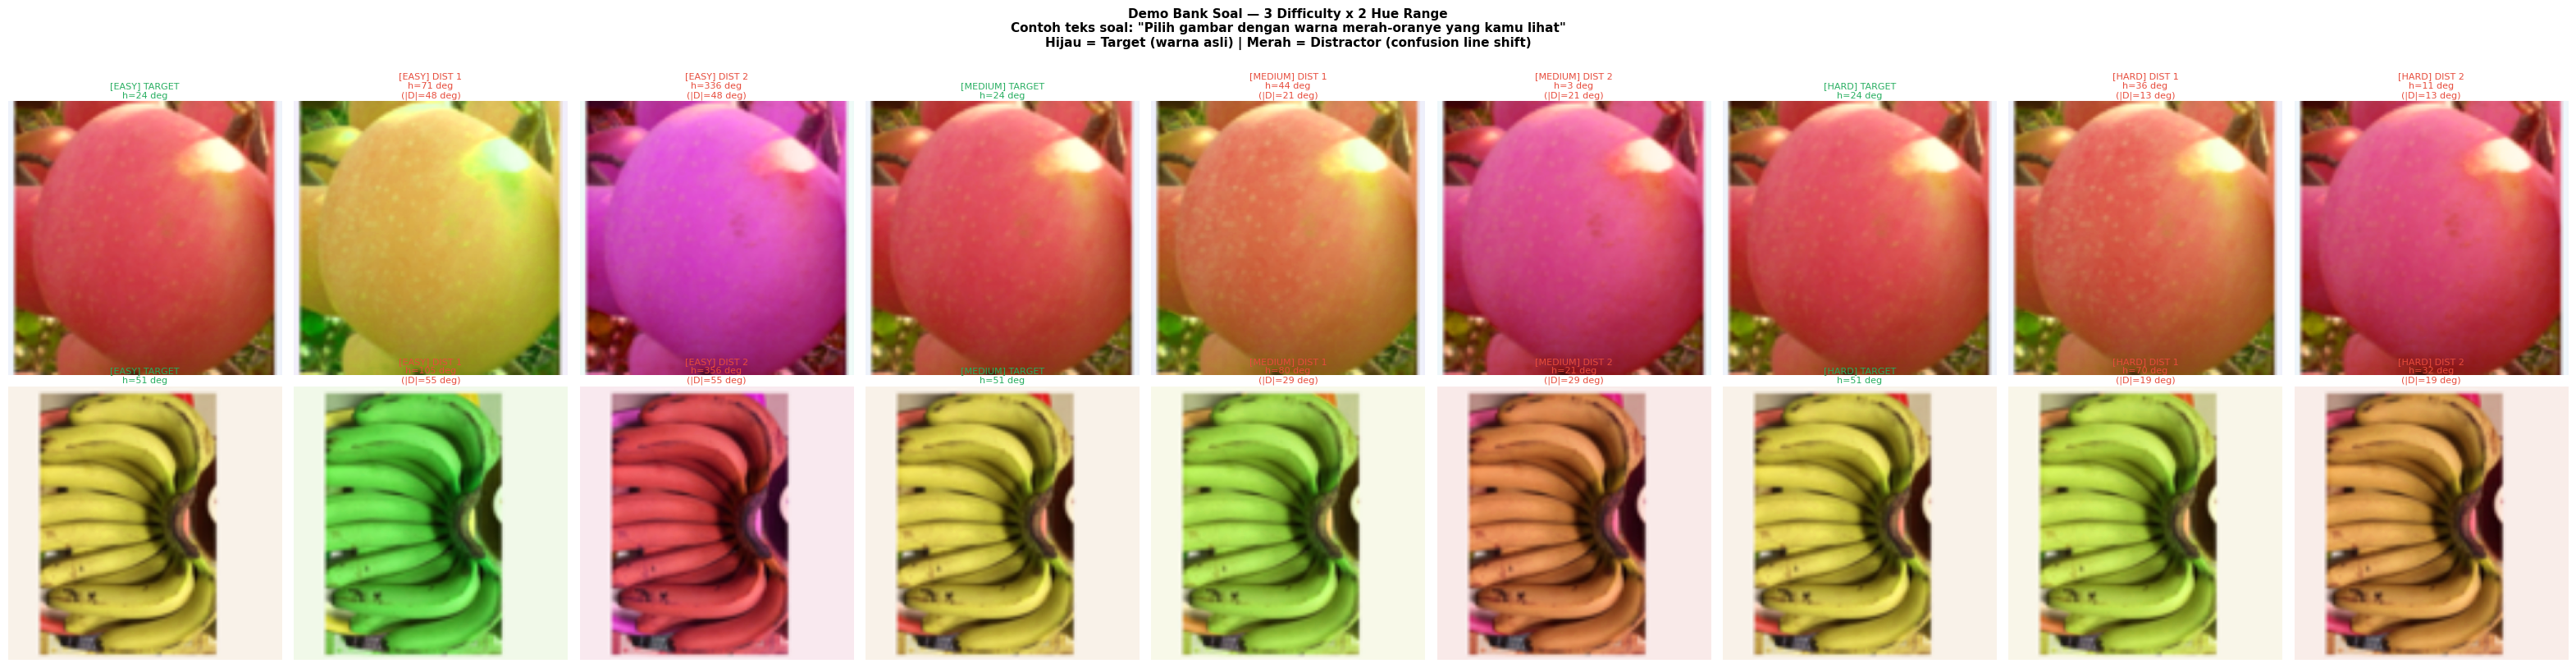

[4E] Demo disimpan: C:\Colorblind_correction\research\notebooks\04\output\demo_quiz.png

  Sample teks soal per kelas:
    apple        h=  23.5  → Pilih gambar dengan warna merah-oranye yang kamu lihat
    banana       h=  50.6  → Pilih gambar dengan warna kuning-oranye yang kamu lihat


In [18]:
# Tahap 4E: Demo visual per difficulty dan hue range
DEMO_SAMPLES: dict[str, dict] = {}
for hr in ["red_orange", "green_yellow"]:
    cands = [r for r in indexed_records if r["hue_range"] == hr]
    if cands:
        DEMO_SAMPLES[hr] = random.Random(RANDOM_SEED).choice(cands)

difficulties = list(DELTA_RANGE.keys())
n_hr   = len(DEMO_SAMPLES)
n_diff = len(difficulties)

fig, axes = plt.subplots(
    n_hr, n_diff * 3,
    figsize=(n_diff * 3 * 3.5, n_hr * 4.0),
)
if n_hr == 1:
    axes = axes[np.newaxis, :]

ROLE_COLORS = {"target": "#27AE60", "dist1": "#E74C3C", "dist2": "#E74C3C"}
ROLE_LABELS = {"target": "TARGET", "dist1": "DIST 1", "dist2": "DIST 2"}

for row_idx, (hr, rec) in enumerate(DEMO_SAMPLES.items()):
    src_path = rec["source_image_path"]
    base_hue = rec["dominant_hue_360"]
    cvd_type = HUE_RANGE_CVD[hr]

    for d_idx, diff in enumerate(difficulties):
        rng_demo = random.Random(RANDOM_SEED + row_idx * 10 + d_idx)
        h1, h2   = generate_distractor_hues(base_hue, hr, diff, rng_demo)

        gap1 = abs((h1 - base_hue + 180) % 360 - 180)
        gap2 = abs((h2 - base_hue + 180) % 360 - 180)

        for c_idx, (role, target_h) in enumerate([
            ("target", base_hue),
            ("dist1",  h1),
            ("dist2",  h2),
        ]):
            ax  = axes[row_idx, d_idx * 3 + c_idx]
            img = apply_hue_shift(src_path, target_h, base_hue)

            if img is not None:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                ax.text(0.5, 0.5, "gagal", ha="center", va="center",
                        transform=ax.transAxes, color="red")

            color = ROLE_COLORS[role]
            delta_info = (
                f"h={target_h:.0f} deg"
                if role == "target"
                else f"h={target_h:.0f} deg\n(|D|={gap1 if role=='dist1' else gap2:.0f} deg)"
            )
            ax.set_title(
                f"[{diff.upper()}] {ROLE_LABELS[role]}\n{delta_info}",
                fontsize=8, color=color, pad=3,
            )
            ax.axis("off")
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_edgecolor(color)
                sp.set_linewidth(2.5)

    axes[row_idx, 0].set_ylabel(
        f"{hr}\n{rec['folder_name']}\nBase h={base_hue:.1f} deg\nCVD: {cvd_type}",
        fontsize=8, color="#2C3E50", fontweight="bold",
    )

q_text_demo = make_question_text(
    list(DEMO_SAMPLES.values())[0]["dominant_hue_360"]
)
plt.suptitle(
    f"Demo Bank Soal — 3 Difficulty x 2 Hue Range\n"
    f"Contoh teks soal: \"{q_text_demo}\"\n"
    "Hijau = Target (warna asli) | Merah = Distractor (confusion line shift)",
    fontsize=11, fontweight="bold", y=1.02,
)
plt.tight_layout()
out_demo = NB04_OUTPUT / "demo_quiz.png"
fig.savefig(str(out_demo), dpi=150, bbox_inches="tight")
plt.show()
print(f"[4E] Demo disimpan: {out_demo}")
print()
print("  Sample teks soal per kelas:")
for hr, rec in DEMO_SAMPLES.items():
    qt = make_question_text(rec["dominant_hue_360"])
    print(f"    {rec['class_name']:<12} h={rec['dominant_hue_360']:>6.1f}  → {qt}")


In [19]:
# Tahap 4F: Generate satu entri soal
_soal_counter: dict[str, int] = {}   # nomor soal per (hue_range, difficulty)

def _next_soal_number(hue_range: str, difficulty: str) -> int:
    """Increment dan kembalikan nomor soal berikutnya (mulai dari 1)."""
    key = f"{hue_range}/{difficulty}"
    _soal_counter[key] = _soal_counter.get(key, 0) + 1
    return _soal_counter[key]


def generate_question_entry(
    record       : dict,
    difficulty   : str,
    images_dir   : Path,
    random_state : int,
) -> dict | None:
    """Generate satu entri soal: 3 gambar (target + 2 distractor) dari satu base image.

    Struktur output: images_dir/{hue_range}/{difficulty}/soal_{N:03d}/{class}_{role}.jpg
    Posisi target di antara 3 pilihan diacak per soal; correct_answer_index
    menyimpan slot target (0/1/2 = A/B/C di UI). Return None jika gambar
    sumber gagal dibaca.
    """
    src_path    = record["source_image_path"]
    folder_name = record["folder_name"]
    class_name  = record["class_name"]
    hue_range   = record["hue_range"]
    base_hue    = record["dominant_hue_360"]
    cvd_type    = HUE_RANGE_CVD[hue_range]

    rng_local = random.Random(random_state)

    hue_d1, hue_d2 = generate_distractor_hues(base_hue, hue_range, difficulty, rng_local)

    soal_num = _next_soal_number(hue_range, difficulty)
    soal_dir = images_dir / hue_range / difficulty / f"soal_{soal_num:03d}"
    soal_dir.mkdir(parents=True, exist_ok=True)

    path_target = soal_dir / f"{class_name}_target.jpg"
    path_dist1  = soal_dir / f"{class_name}_dist1.jpg"
    path_dist2  = soal_dir / f"{class_name}_dist2.jpg"

    img_target = apply_hue_shift(src_path, base_hue, base_hue)
    img_dist1  = apply_hue_shift(src_path, hue_d1,  base_hue)
    img_dist2  = apply_hue_shift(src_path, hue_d2,  base_hue)

    if any(i is None for i in (img_target, img_dist1, img_dist2)):
        return None

    for img, path in (
        (img_target, path_target),
        (img_dist1,  path_dist1),
        (img_dist2,  path_dist2),
    ):
        if not save_image(img, path):
            return None

    order = [0, 1, 2]   # order[0]=slot target, order[1]=slot dist1, order[2]=slot dist2
    rng_local.shuffle(order)

    option_paths: list[str] = ["", "", ""]
    option_paths[order[0]] = str(path_target.relative_to(RESEARCH_ROOT))
    option_paths[order[1]] = str(path_dist1.relative_to(RESEARCH_ROOT))
    option_paths[order[2]] = str(path_dist2.relative_to(RESEARCH_ROOT))

    delta_d1 = round(abs((hue_d1 - base_hue + 180) % 360 - 180), 2)
    delta_d2 = round(abs((hue_d2 - base_hue + 180) % 360 - 180), 2)

    return {
        "question_id"          : str(uuid.uuid4()),
        "soal_number"          : soal_num,
        "folder_name"          : folder_name,
        "class_name"           : class_name,
        "hue_range"            : hue_range,
        "cvd_type_target"      : cvd_type,
        "difficulty"           : difficulty,
        "error_weight"         : ERROR_WEIGHT[difficulty],
        "question_text"        : make_question_text(base_hue),
        "base_hue_360"         : round(base_hue, 2),
        "distractor_hues"      : [round(hue_d1, 2), round(hue_d2, 2)],
        "distractor_deltas_deg": [delta_d1, delta_d2],
        "correct_answer_index" : order[0],
        "option_0_path"        : option_paths[0],
        "option_1_path"        : option_paths[1],
        "option_2_path"        : option_paths[2],
    }


print("[Cell 8] Fungsi generate_question_entry siap.")
print()


[Cell 8] Fungsi generate_question_entry siap.



In [20]:
def build_question_bank(
    indexed_records: list[dict],
    images_dir     : Path,
) -> tuple[list[dict], int]:
    """Generate bank soal dari semua indexed records — 3 soal (1 per difficulty) per record.

    Seed per soal deterministik: RANDOM_SEED + idx*100 + d_idx.
    Return (bank, n_failed_render) — n_failed_render dihitung dari
    generate_question_entry() yang mengembalikan None (cv2.imread gagal).
    """
    difficulties    = list(DELTA_RANGE.keys())
    bank            : list[dict] = []
    n_failed_render : int        = 0

    for idx, rec in tqdm(
        enumerate(indexed_records),
        total=len(indexed_records),
        desc="  Generating",
        ncols=80,
    ):
        for d_idx, diff in enumerate(difficulties):
            seed  = RANDOM_SEED + idx * 100 + d_idx
            entry = generate_question_entry(
                record=rec,
                difficulty=diff,
                images_dir=images_dir,
                random_state=seed,
            )
            if entry is not None:
                bank.append(entry)
            else:
                n_failed_render += 1

    return bank, n_failed_render


n_per = len(DELTA_RANGE)
print(f"[4G] Batch generation dimulai...")
print(f"  Indexed records    : {len(indexed_records):,}")
print(f"  Soal per record    : {n_per} (3 difficulty)")
print(f"  Estimasi total     : {len(indexed_records) * n_per:,}")
print()

_soal_counter.clear()   # reset agar nomor soal mulai dari 1 jika cell dijalankan ulang

question_bank, n_failed_render = build_question_bank(indexed_records, IMAGES_DIR)

print()
print(f"[4G] Selesai:")
print(f"  Soal di-generate   : {len(question_bank):,}")
print(f"  Gagal render       : {n_failed_render:,}  (cv2.imread gagal / file korup)")


[4G] Batch generation dimulai...
  Indexed records    : 1,228
  Soal per record    : 3 (3 difficulty)
  Estimasi total     : 3,684



  Generating:   0%|                                    | 0/1228 [00:00<?, ?it/s]

  Generating: 100%|█████████████████████████| 1228/1228 [01:19<00:00, 15.42it/s]


[4G] Selesai:
  Soal di-generate   : 3,684
  Gagal render       : 0  (cv2.imread gagal / file korup)


  Validasi: 100%|███████████████| 3684/3684 [00:00<00:00, 6119.71it/s]


  Total di-generate : 3,684
  Valid             : 3,684  (100.0%)
  Invalid           : 0

  Per difficulty:
    easy    : 1,228  delta 35.0-55.0 deg
    medium  : 1,228  delta 20.0-35.0 deg
    hard    : 1,228  delta 8.0-20.0 deg

  Per hue range → CVD type:
    red_orange     (protanopia   ): 1,842
    green_yellow   (deuteranopia ): 1,842

  Crosstab difficulty x hue_range:
                green_yellow      red_orange     total
  ────────────────────────────────────────────────────
  easy                   614             614     1,228
  medium                 614             614     1,228
  hard                   614             614     1,228


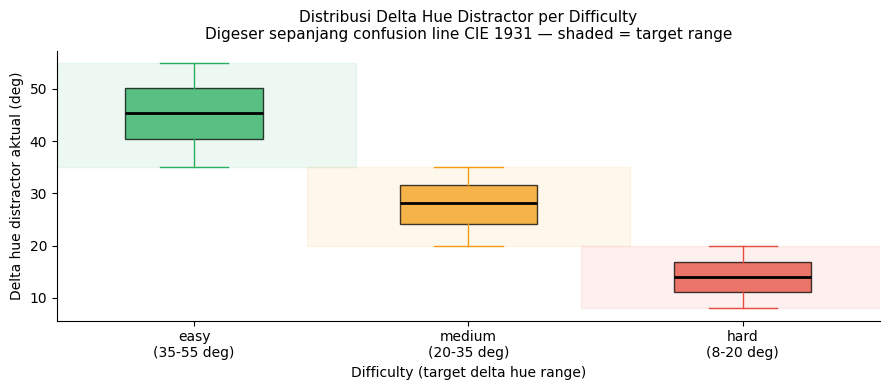

[4H] Plot disimpan: C:\Colorblind_correction\research\notebooks\04\output\delta_distribution.png


In [21]:
# Tahap 4H: Validasi & statistik
def validate_entry(entry: dict) -> list[str]:
    """Validasi satu entri soal: file gambar ada, correct_answer_index valid (0-2),
    delta hue dalam toleransi +-30% dari DELTA_RANGE, dan selisih antar distractor
    >= MIN_DISTRACTOR_DIFF. Return list error, kosong jika valid.
    """
    errors: list[str] = []

    for field in ("option_0_path", "option_1_path", "option_2_path"):
        rel = entry.get(field, "")
        if not rel:
            errors.append(f"{field} kosong")
        elif not (RESEARCH_ROOT / rel).exists():
            errors.append(f"file tidak ada: {rel}")

    # Cek correct_answer_index
    if entry.get("correct_answer_index") not in (0, 1, 2):
        errors.append(f"correct_answer_index invalid: {entry.get('correct_answer_index')}")

    # Cek delta hue dalam toleransi
    diff   = entry.get("difficulty", "")
    deltas = entry.get("distractor_deltas_deg", [])
    if diff and deltas and diff in DELTA_RANGE:
        d_min, d_max = DELTA_RANGE[diff]
        tol_lo = d_min * 0.70
        tol_hi = d_max * 1.30
        for d in deltas:
            if not (tol_lo <= d <= tol_hi):
                errors.append(
                    f"delta={d:.1f} deg di luar toleransi '{diff}' "
                    f"(valid: {tol_lo:.1f}-{tol_hi:.1f} deg)"
                )

    return errors


valid_bank   : list[dict] = []
invalid_bank : list[dict] = []

for entry in tqdm(question_bank, desc="  Validasi", ncols=70):
    if not validate_entry(entry):
        valid_bank.append(entry)
    else:
        invalid_bank.append(entry)

n_invalid = len(invalid_bank)

diff_counts = Counter(e["difficulty"]      for e in valid_bank)
cvd_counts  = Counter(e["cvd_type_target"] for e in valid_bank)
hue_counts  = Counter(e["hue_range"]       for e in valid_bank)

if invalid_bank:
    reason_counts: Counter = Counter()
    for entry in invalid_bank:
        for err in validate_entry(entry):
            reason = err.split(":")[0].strip()   # ambil prefix error untuk grouping
            reason_counts[reason] += 1
    print(f"  [DEBUG] Penyebab invalid ({n_invalid} soal):")
    for reason, cnt in reason_counts.most_common():
        print(f"    {cnt:>5}x  {reason}")
    print()

print(f"  Total di-generate : {len(question_bank):,}")
print(f"  Valid             : {len(valid_bank):,}  "
      f"({len(valid_bank)/max(len(question_bank),1)*100:.1f}%)")
print(f"  Invalid           : {n_invalid:,}")
print()
print("  Per difficulty:")
for d in ["easy","medium","hard"]:
    n = diff_counts.get(d, 0)
    deltas_d = [
        x for e in valid_bank if e["difficulty"] == d
        for x in e.get("distractor_deltas_deg", [])
    ]
    rng_str = (f"  delta {min(deltas_d):.1f}-{max(deltas_d):.1f} deg"
               if deltas_d else "")
    print(f"    {d:<8}: {n:,}{rng_str}")
print()
print("  Per hue range → CVD type:")
for hr, cvd in HUE_RANGE_CVD.items():
    print(f"    {hr:<14} ({cvd:<13}): {hue_counts.get(hr, 0):,}")

# Crosstab
hues  = sorted(hue_counts.keys())
diffs = ["easy","medium","hard"]
print()
print("  Crosstab difficulty x hue_range:")
hdr = f"  {'':10}" + "".join(f"  {h:>14}" for h in hues) + f"  {'total':>8}"
print(hdr)
print("  " + "─" * (10 + 16*len(hues) + 10))
for diff in diffs:
    row = [
        sum(1 for e in valid_bank
            if e["difficulty"]==diff and e["hue_range"]==h)
        for h in hues
    ]
    print(f"  {diff:<10}" + "".join(f"  {v:>14,}" for v in row)
          + f"  {sum(row):>8,}")

# Plot distribusi delta hue
deltas_by_diff: dict[str, list[float]] = {d: [] for d in diffs}
for e in valid_bank:
    for x in e.get("distractor_deltas_deg", []):
        deltas_by_diff[e["difficulty"]].append(x)

fig, ax = plt.subplots(figsize=(9, 4))
DIFF_COLORS = {"easy": "#27AE60", "medium": "#F39C12", "hard": "#E74C3C"}

for i, diff in enumerate(diffs):
    vals = deltas_by_diff[diff]
    if not vals:
        continue
    ax.boxplot(
        vals, positions=[i], widths=0.5, patch_artist=True,
        boxprops    =dict(facecolor=DIFF_COLORS[diff], alpha=0.75),
        medianprops =dict(color="black", lw=2),
        whiskerprops=dict(color=DIFF_COLORS[diff]),
        capprops    =dict(color=DIFF_COLORS[diff]),
        flierprops  =dict(marker="o", ms=3, alpha=0.3,
                         markerfacecolor=DIFF_COLORS[diff]),
    )
    d_lo, d_hi = DELTA_RANGE[diff]
    ax.axhspan(d_lo, d_hi, alpha=0.08, color=DIFF_COLORS[diff],
               xmin=i/len(diffs)-0.03, xmax=(i+1)/len(diffs)+0.03)

ax.set_xticks(range(len(diffs)))
ax.set_xticklabels([
    f"{d}\n({DELTA_RANGE[d][0]:.0f}-{DELTA_RANGE[d][1]:.0f} deg)"
    for d in diffs
])
ax.set_xlabel("Difficulty (target delta hue range)", fontsize=10)
ax.set_ylabel("Delta hue distractor aktual (deg)", fontsize=10)
ax.set_title(
    "Distribusi Delta Hue Distractor per Difficulty\n"
    "Digeser sepanjang confusion line CIE 1931 — shaded = target range",
    fontsize=11, pad=8,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
out_dist = NB04_OUTPUT / "delta_distribution.png"
fig.savefig(str(out_dist), dpi=150, bbox_inches="tight")
plt.show()
print(f"[4H] Plot disimpan: {out_dist}")


In [22]:
def _build_statistics(
    valid_bank      : list[dict],
    question_bank   : list[dict],
    indexed_records : list[dict],
    n_failed_render : int,
) -> dict:
    """Bangun statistik ringkas question bank, memisahkan n_failed_render
    (gagal di tahap generate) vs n_invalid_delta (berhasil tapi delta di luar toleransi).
    """
    diff_c = Counter(e["difficulty"]      for e in valid_bank)
    cvd_c  = Counter(e["cvd_type_target"] for e in valid_bank)
    hue_c  = Counter(e["hue_range"]       for e in valid_bank)

    n_generated = len(question_bank)
    n_valid     = len(valid_bank)
    n_invalid_delta = n_generated - n_valid

    delta_stats: dict[str, dict] = {}
    for diff in DELTA_RANGE:
        deltas = [
            x for e in valid_bank if e["difficulty"] == diff
            for x in e.get("distractor_deltas_deg", [])
        ]
        if deltas:
            delta_stats[diff] = {
                "target_range_deg": list(DELTA_RANGE[diff]),
                "actual_min_deg"  : round(min(deltas), 2),
                "actual_max_deg"  : round(max(deltas), 2),
                "actual_mean_deg" : round(float(np.mean(deltas)), 2),
            }

    return {
        "total_indexed_records" : len(indexed_records),
        "total_generated"       : n_generated,
        "total_valid"           : n_valid,
        "n_failed_render"       : n_failed_render,
        "n_invalid_delta"       : n_invalid_delta,
        "valid_rate_pct"        : round(n_valid / max(n_generated, 1) * 100, 1),
        "per_difficulty"        : {d: diff_c.get(d, 0) for d in DELTA_RANGE},
        "per_cvd_type"          : dict(cvd_c),
        "per_hue_range"         : dict(hue_c),
        "delta_hue_stats"       : delta_stats,
    }


stats = _build_statistics(valid_bank, question_bank, indexed_records, n_failed_render)

payload: dict = {
    "build_timestamp"  : datetime.datetime.now().isoformat(),
    "notebook_version" : "NB04",
    "design_rationale": {
        "image_indexing": (
            "NB04 membangun image index dari scan direktori fruit_filtered "
            "dan menjoinnya dengan extraction_results.json via posisi index. "
            "Ini menyelesaikan duplikasi source image yang disebabkan "
            "undersampling NB02 (1873 RO records vs 688 RO files)."
        ),
        "question_framing": (
            "Teks soal dinamis per soal ('Pilih gambar dengan warna X') "
            "berdasarkan hue dominan target, mencegah user menghafal "
            "pola teks yang sama untuk semua soal satu hue range."
        ),
        "distractor_selection": (
            "Distractor dipilih dari confusion line CIE 1931 — garis yang "
            "menghubungkan warna tidak dapat dibedakan penderita CVD. "
            "Perbedaan target-distractor tidak terdeteksi CVD tapi jelas "
            "bagi penglihatan normal (delta dikendalikan per difficulty)."
        ),
        "difficulty_design": (
            "Easy: delta 35-55 deg — perbedaan sangat jelas bagi mata normal. "
            "Medium: delta 18-35 deg — perlu perhatian. "
            "Hard: delta 5-18 deg — sangat halus tapi masih bisa dibedakan."
        ),
        "hue_range_cvd_mapping": (
            "red_orange → protanopia (cone-L deficiency, konfusi merah-oranye). "
            "green_yellow → deuteranopia (cone-M deficiency, konfusi hijau-kuning). "
            "Sumber: Brettel et al. (1997); Cole & Lian (2006)."
        ),
    },
    "parameters": {
        "copunctal_points"    : COPUNCTAL,
        "white_point_d65"     : WHITE_D65,
        "hue_range_cvd"       : HUE_RANGE_CVD,
        "delta_range_deg"     : DELTA_RANGE,
        "min_distractor_diff" : MIN_DISTRACTOR_DIFF,
        "error_weight"        : ERROR_WEIGHT,
        "target_size_px"      : TARGET_SIZE,
        "jpeg_quality"        : JPEG_QUALITY,
        "random_seed"         : RANDOM_SEED,
    },
    "statistics" : stats,
    "questions"  : valid_bank,
}

out_json = NB04_OUTPUT / "question_bank.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False)

file_mb = out_json.stat().st_size / (1024 * 1024)

print(f"[4I] Ekspor selesai: {out_json}")
print(f"     Ukuran file   : {file_mb:.2f} MB")
print()
print("  RINGKASAN NB04")
print(f"  Indexed records   : {stats['total_indexed_records']:,}")
print(f"  Soal di-generate  : {stats['total_generated']:,}")
print(f"  Gagal render      : {stats['n_failed_render']:,}  (cv2 gagal baca file)")
print(f"  Invalid delta     : {stats['n_invalid_delta']:,}  (delta di luar toleransi)")
print(f"  Valid             : {stats['total_valid']:,}  ({stats['valid_rate_pct']}%)")
print()
print("  Per difficulty:")
for d in ["easy","medium","hard"]:
    n   = stats["per_difficulty"].get(d, 0)
    dst = stats["delta_hue_stats"].get(d, {})
    lo  = dst.get("actual_min_deg", "?")
    hi  = dst.get("actual_max_deg", "?")
    print(f"    {d:<8}: {n:,}  delta {lo}-{hi} deg")
print()
print("  Per hue range → CVD type:")
for hr, cvd in HUE_RANGE_CVD.items():
    print(f"    {hr:<14} ({cvd}): {stats['per_hue_range'].get(hr,0):,}")
print()
print(f"  Output: {NB04_OUTPUT}")


[4I] Ekspor selesai: C:\Colorblind_correction\research\notebooks\04\output\question_bank.json
     Ukuran file   : 2.63 MB

  RINGKASAN NB04
  Indexed records   : 1,228
  Soal di-generate  : 3,684
  Gagal render      : 0  (cv2 gagal baca file)
  Invalid delta     : 0  (delta di luar toleransi)
  Valid             : 3,684  (100.0%)

  Per difficulty:
    easy    : 1,228  delta 35.0-55.0 deg
    medium  : 1,228  delta 20.01-34.99 deg
    hard    : 1,228  delta 8.0-19.99 deg

  Per hue range → CVD type:
    red_orange     (protanopia): 1,842
    green_yellow   (deuteranopia): 1,842

  Output: C:\Colorblind_correction\research\notebooks\04\output


## Catatan Metodologis

**Validasi tiap entri soal (Cell 10):**
1. Tiga file gambar ada di disk
2. `correct_answer_index` valid (0, 1, atau 2)
3. Delta hue distractor dalam toleransi ±30% dari `DELTA_RANGE[difficulty]`
4. Selisih antar dua distractor ≥ `MIN_DISTRACTOR_DIFF` (8°)

**Struktur folder output:**
```
quiz_images/
├── red_orange/
│   ├── easy/
│   │   ├── soal_001/
│   │   │   ├── strawberry_target.jpg
│   │   │   ├── strawberry_dist1.jpg
│   │   │   └── strawberry_dist2.jpg
│   │   └── soal_002/
│   ├── medium/
│   └── hard/
└── green_yellow/
    ├── easy/
    ├── medium/
    └── hard/
```

**Output yang dibaca NB05:** `question_bank.json` berisi `question_text`
(dinamis per soal), `option_0/1/2_path` (path relatif tiga gambar), dan
`correct_answer_index` untuk adaptive quiz engine.
